In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

# Data Cleaning And Create Features

In [35]:
df = pd.read_csv("war_economic_impact_dataset.csv")

df.head()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,...,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,...,97.41,170.33,106957216228,209054555175,15.50,27.09,High,food,10.50,No
1,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),8.18,23.00,14.82,...,73.68,41.97,304164881098,585915946162,11.95,34.76,Dominant,fuel,19.31,No
2,Syrian Civil War,Civil War,Middle East,2011,2026,Ongoing,Syria,12.70,36.46,23.76,...,69.35,53.91,484822729254,1666739121273,38.18,90.00,Moderate,"water, weapons, currency",298.95,No
3,WWII (Germany),World War,Europe,1939,1945,Resolved,Germany,14.06,17.83,3.77,...,36.92,48.51,71321188262,250015887113,12.24,36.42,Moderate,"currency, medicine, weapons",15.44,No
4,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,5.38,5.98,0.59,...,52.62,31.32,156180178536,361238241031,31.89,74.86,Dominant,medicine,443.61,Yes


In [36]:
print(df.shape)



(100000, 28)


In [37]:
print(df.isnull().sum())

Conflict_Name                              0
Conflict_Type                              0
Region                                     0
Start_Year                                 0
End_Year                                   0
Status                                     0
Primary_Country                            0
Pre_War_Unemployment_%                     0
During_War_Unemployment_%                  0
Unemployment_Spike_Percentage_Points       0
Most_Affected_Sector                       0
Youth_Unemployment_Change_%                0
Pre_War_Poverty_Rate_%                     0
During_War_Poverty_Rate_%                  0
Extreme_Poverty_Rate_%                     0
Food_Insecurity_Rate_%                     0
Households_Fallen_Into_Poverty_Estimate    0
GDP_Change_%                               0
Inflation_Rate_%                           0
Currency_Devaluation_%                     0
Cost_of_War_USD                            0
Estimated_Reconstruction_Cost_USD          0
Informal_E

In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   Conflict_Name                            100000 non-null  object 
 1   Conflict_Type                            100000 non-null  object 
 2   Region                                   100000 non-null  object 
 3   Start_Year                               100000 non-null  int64  
 4   End_Year                                 100000 non-null  int64  
 5   Status                                   100000 non-null  object 
 6   Primary_Country                          100000 non-null  object 
 7   Pre_War_Unemployment_%                   100000 non-null  float64
 8   During_War_Unemployment_%                100000 non-null  float64
 9   Unemployment_Spike_Percentage_Points     100000 non-null  float64
 10  Most_Affected_Sector             

In [39]:
print(df.dtypes)

Conflict_Name                               object
Conflict_Type                               object
Region                                      object
Start_Year                                   int64
End_Year                                     int64
Status                                      object
Primary_Country                             object
Pre_War_Unemployment_%                     float64
During_War_Unemployment_%                  float64
Unemployment_Spike_Percentage_Points       float64
Most_Affected_Sector                        object
Youth_Unemployment_Change_%                float64
Pre_War_Poverty_Rate_%                     float64
During_War_Poverty_Rate_%                  float64
Extreme_Poverty_Rate_%                     float64
Food_Insecurity_Rate_%                     float64
Households_Fallen_Into_Poverty_Estimate      int64
GDP_Change_%                               float64
Inflation_Rate_%                           float64
Currency_Devaluation_%         

## Engineer New Columns

In [40]:
# Feature Engineering

# Feature of duration of war
df['War_duration_year'] = df['End_Year'] - df['Start_Year']

# Poverty increase

df['Poverty_Increase'] = df['During_War_Poverty_Rate_%'] - df['Pre_War_Poverty_Rate_%']

# Unemployment increase

df['Unemployment_Increase'] = df['During_War_Unemployment_%'] - df['Pre_War_Unemployment_%']

# Reconstruction_Ratio

df['Reconstruction_Ratio'] = df['Estimated_Reconstruction_Cost_USD'] / df['Cost_of_War_USD']

# Checking the Features
df.head()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,...,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented,War_duration_year,Poverty_Increase,Unemployment_Increase,Reconstruction_Ratio
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,...,15.50,27.09,High,food,10.50,No,6,8.70,14.29,1.954562
1,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),8.18,23.00,14.82,...,11.95,34.76,Dominant,fuel,19.31,No,3,10.44,14.82,1.926310
2,Syrian Civil War,Civil War,Middle East,2011,2026,Ongoing,Syria,12.70,36.46,23.76,...,38.18,90.00,Moderate,"water, weapons, currency",298.95,No,15,19.20,23.76,3.437832
3,WWII (Germany),World War,Europe,1939,1945,Resolved,Germany,14.06,17.83,3.77,...,12.24,36.42,Moderate,"currency, medicine, weapons",15.44,No,6,2.74,3.77,3.505492
4,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,5.38,5.98,0.59,...,31.89,74.86,Dominant,medicine,443.61,Yes,20,0.60,0.60,2.312958


In [41]:
df['Black_Market_Activity_Level'].unique()


array(['High', 'Dominant', 'Moderate', 'Low'], dtype=object)

In [42]:
df['War_Profiteering_Documented'].unique()

array(['No', 'Yes'], dtype=object)

In [43]:
df['Black_Market_Activity_Level'] = df['Black_Market_Activity_Level'].str.strip().map({'Low':1,'Moderate':2,'High':3,'Dominant':4})

df['War_Profiteering_Documented'] = df['War_Profiteering_Documented'].str.strip().map({'No':0,'Yes':1})

df.head()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,...,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented,War_duration_year,Poverty_Increase,Unemployment_Increase,Reconstruction_Ratio
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,...,15.50,27.09,3,food,10.50,0,6,8.70,14.29,1.954562
1,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),8.18,23.00,14.82,...,11.95,34.76,4,fuel,19.31,0,3,10.44,14.82,1.926310
2,Syrian Civil War,Civil War,Middle East,2011,2026,Ongoing,Syria,12.70,36.46,23.76,...,38.18,90.00,2,"water, weapons, currency",298.95,0,15,19.20,23.76,3.437832
3,WWII (Germany),World War,Europe,1939,1945,Resolved,Germany,14.06,17.83,3.77,...,12.24,36.42,2,"currency, medicine, weapons",15.44,0,6,2.74,3.77,3.505492
4,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,5.38,5.98,0.59,...,31.89,74.86,4,medicine,443.61,1,20,0.60,0.60,2.312958


In [44]:
df.describe()

,Start_Year,End_Year,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,...,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented,War_duration_year,Poverty_Increase,Unemployment_Increase,Reconstruction_Ratio
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1999.401340,2009.039940,9.017027,22.625199,13.608182,17.686763,17.518820,29.077186,14.553542,20.351211,...,6.895004e+11,25.002639,51.783920,2.502170,126.181130,0.699740,9.638600,11.558365,13.608172,2.749633
std,29.957153,30.552183,3.458406,13.818295,11.960175,15.678211,7.217439,13.000781,7.487060,9.790643,...,4.471766e+11,8.648263,21.266786,1.117187,156.324982,0.458373,8.486171,10.790299,11.960159,0.722480
min,1939.000000,1945.000000,3.000000,3.360000,0.320000,0.360000,5.000000,5.400000,1.840000,3.100000,...,1.617224e+09,10.000000,12.140000,1.000000,0.000000,0.000000,1.000000,0.190000,0.320000,1.500013
25%,1996.000000,2011.000000,6.030000,12.780000,5.330000,6.860000,11.260000,20.030000,9.270000,13.490000,...,3.239366e+11,17.520000,34.420000,2.000000,9.330000,0.000000,3.000000,4.260000,5.330000,2.123971
50%,2011.000000,2026.000000,9.020000,19.480000,10.220000,13.245000,17.520000,27.630000,13.200000,18.800000,...,6.367629e+11,25.010000,49.190000,3.000000,18.760000,1.000000,6.000000,8.390000,10.220000,2.748370
75%,2022.000000,2026.000000,12.000000,28.800000,17.890000,23.270000,23.790000,35.290000,18.250000,25.200000,...,9.934733e+11,32.490000,67.820000,3.000000,241.432500,1.000000,15.000000,15.050000,17.890000,3.378639
max,2025.000000,2026.000000,15.000000,89.400000,74.470000,108.710000,30.000000,98.000000,68.490000,86.320000,...,1.997802e+12,40.000000,90.000000,4.000000,500.000000,1.000000,30.000000,84.470000,74.480000,3.999980


#  Exploratory Data Analysis (EDA)

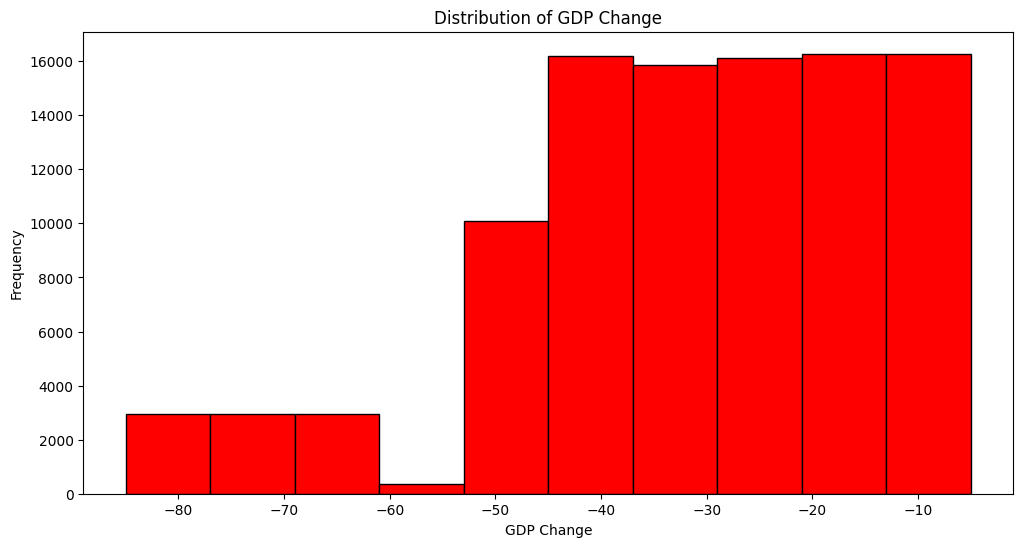

In [45]:
# Distribution plots

plt.figure(figsize=(12,6))
plt.hist(df['GDP_Change_%'],bins=10,color='red',edgecolor='black')
plt.title('Distribution of GDP Change')
plt.xlabel('GDP Change')
plt.ylabel('Frequency')
plt.show()


- GDP_Change_% — Left Skewed (Negative Skew)
- The tail pulls toward the left (very large negative values like −85%). Most wars cause a GDP drop clustered around −20% to −40%, but a few extreme conflicts like Palestine/Gaza drag the tail far left.

- Most countries suffer a "typical" war-level GDP hit, but asymmetric wars and civil wars in weaker economies cause catastrophic outliers. The mean (−31.6%) is being pulled lower than the median by those extremes.

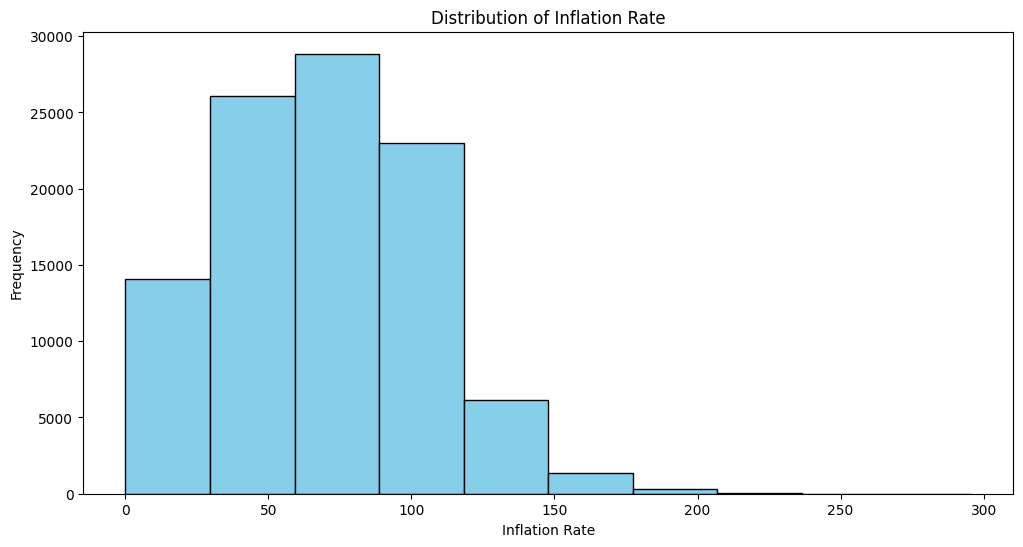

In [46]:
plt.figure(figsize=(12,6))
plt.hist(df['Inflation_Rate_%'],bins=10,color='skyblue',edgecolor='black')
plt.title('Distribution of Inflation Rate')
plt.xlabel('Inflation Rate')
plt.ylabel('Frequency')
plt.show()

- Inflation_Rate_% — Right Skewed (Positive Skew)
- The tail pulls toward the right (extreme inflation spikes up to 295%). Most conflicts sit in the 40–90% range, but hyperinflation outliers (like DRC, Yemen, Afghanistan) stretch the distribution rightward.

- Inflation is "normally bad" in most wars, but a subset of conflicts trigger runaway hyperinflation — usually when the government prints money to fund the war.

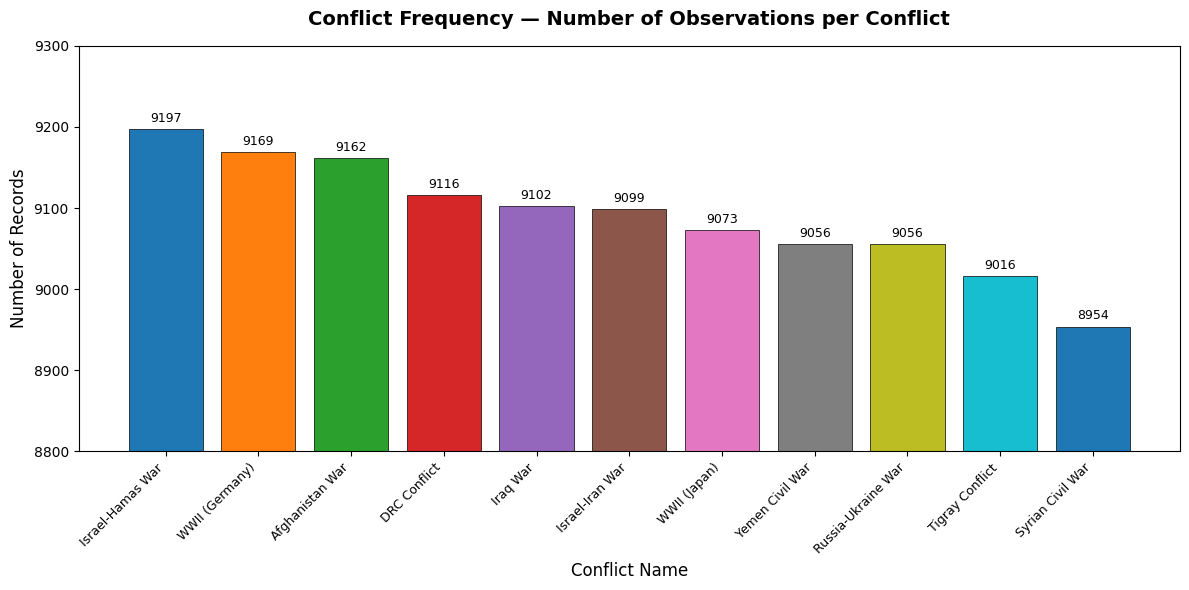

In [47]:
import os
# Conflict Frequency — Bar Chart

conflict_count = df['Conflict_Name'].value_counts().sort_values(ascending=False)

# Plot

fig, ax = plt.subplots(figsize=(12,6))

color = plt.cm.tab10.colors[:len(conflict_count)]

bar = ax.bar(conflict_count.index,conflict_count.values,color=color,edgecolor='black',linewidth=0.5)

# Value lable on top pf each bar
ax.bar_label(bar,fmt='%d',padding=3,fontsize=9)

# Zoom Y-axis to show all differences
ax.set_ylim(8800,9300)


# Labels and title
ax.set_title('Conflict Frequency — Number of Observations per Conflict', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Conflict Name', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)

# Clean x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()

# Create the 'outputs' directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/conflict_frequency.png', dpi=150)
plt.show()

- All 11 conflicts are nearly equally represented with 8,954 to 9,197 records each — a difference of only 243 rows. This confirms a balanced dataset with no sampling bias. Any economic differences found across conflicts in subsequent analysis reflect genuine variation in war impact, not data quantity.

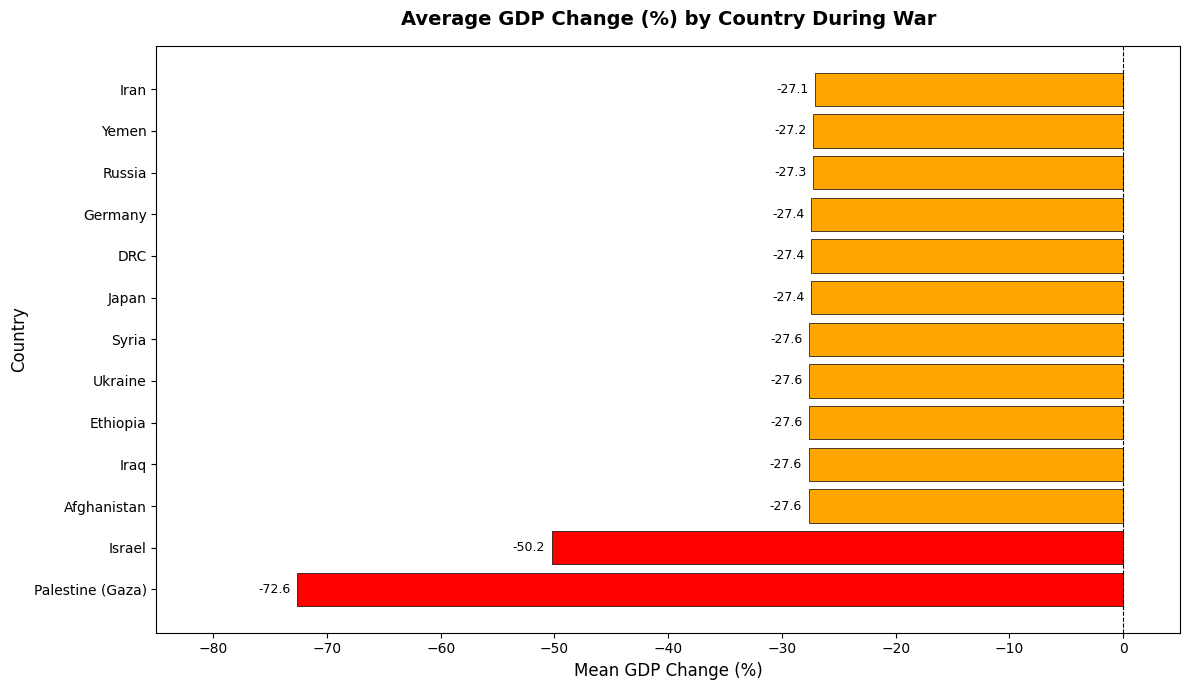

In [48]:
# Mean GDP Change per Country
gdp_by_country = df.groupby('Primary_Country')['GDP_Change_%'].mean().sort_values()

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['red' if x < -40 else 'orange' if x < -25 else 'steelblue'
          for x in gdp_by_country.values]

bars = ax.barh(gdp_by_country.index, gdp_by_country.values,
               color=colors, edgecolor='black', linewidth=0.5)

ax.bar_label(bars, fmt='%.1f', padding=5, fontsize=9)

ax.set_xlim(-85, 5)   # ← gives room for labels
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

ax.set_title('Average GDP Change (%) by Country During War',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mean GDP Change (%)', fontsize=12)
ax.set_ylabel('Country', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/gdp_by_country.png', dpi=150)
plt.show()

- Palestine (Gaza) recorded the most severe average GDP contraction at −72.6%, nearly 45 percentage points worse than the next country (Israel at −50.2%). This reflects the catastrophic economic destruction of asymmetric warfare on a small, aid-dependent economy. The remaining 11 countries cluster tightly between −27.1% and −27.6%, suggesting that despite different conflict types and regions, wars tend to produce a consistent baseline level of economic damage — approximately one quarter of GDP lost on average.

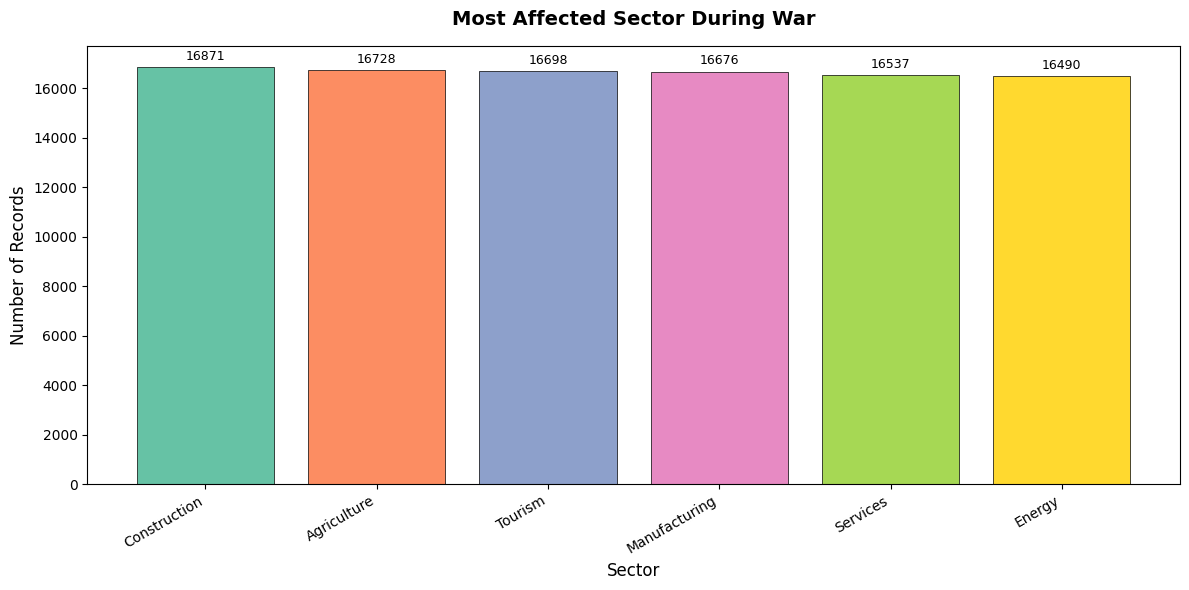

In [49]:
# Most Affected Sector

sector_count = df['Most_Affected_Sector'].value_counts().sort_values(ascending=False)

fig,ax = plt.subplots(figsize=(12,6))

color = plt.cm.Set2.colors[:len(sector_count)]
bars = ax.bar(sector_count.index,sector_count.values,color=color,edgecolor='black',linewidth=0.5)

# Value lable on top pf each bar
ax.bar_label(bars,fmt='%d',padding=3,fontsize=9)

ax.set_title('Most Affected Sector During War', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/most_affected_sector.png', dpi=150)
plt.show()

- All six sectors — Construction, Agriculture, Tourism, Manufacturing, Services, and Energy — are almost equally affected across conflicts, with record counts ranging from 16,490 to 16,871. This uniform distribution suggests that war does not systematically target one sector exclusively but disrupts entire economies broadly. Construction leads marginally, consistent with the physical destruction that accompanies most armed conflicts.

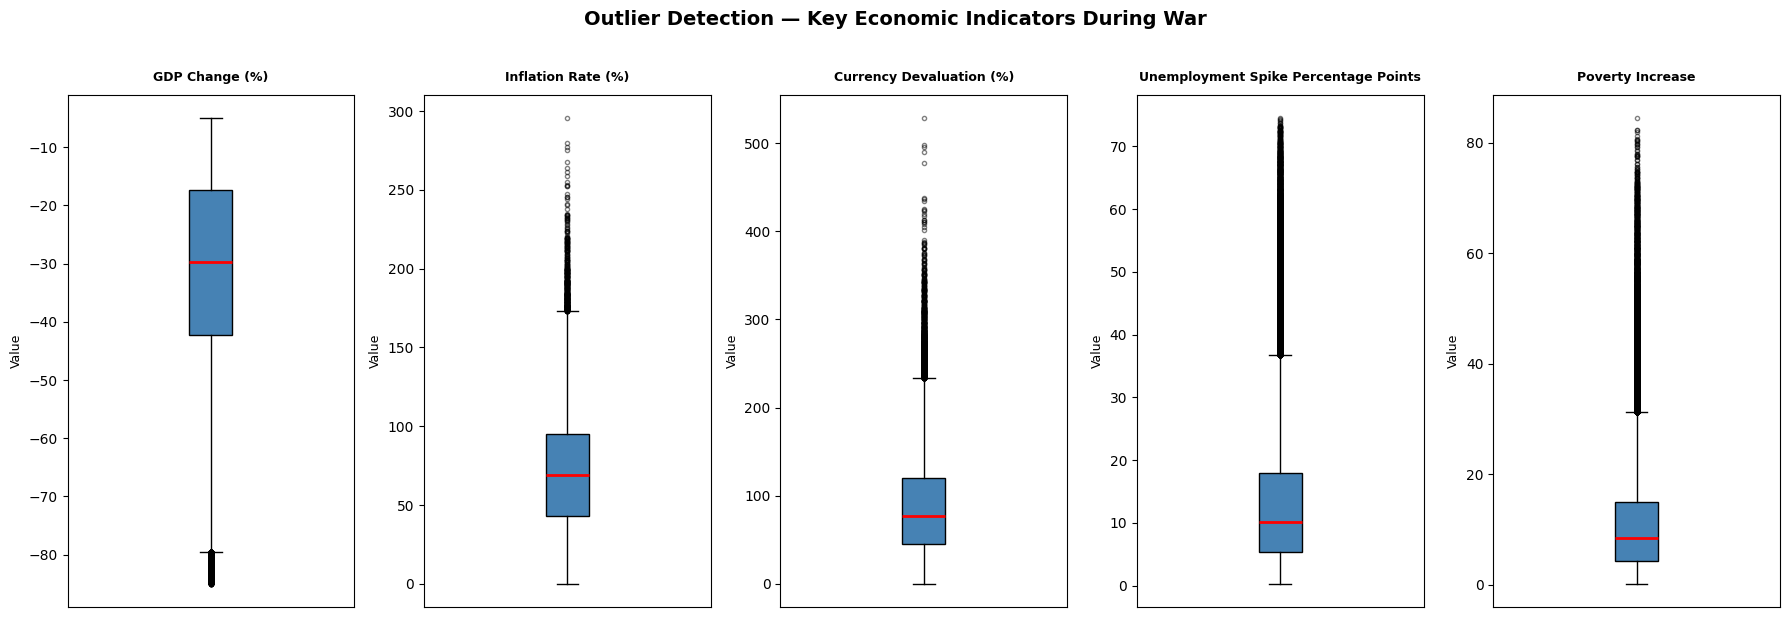

In [50]:
# Columns to check for outliers
cols = [
    'GDP_Change_%',
    'Inflation_Rate_%',
    'Currency_Devaluation_%',
    'Unemployment_Spike_Percentage_Points',
    'Poverty_Increase'
]

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, col in enumerate(cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange',
                                   markersize=3, alpha=0.5))

    axes[i].set_title(col.replace('_', ' ').replace('%', '(%)'),
                      fontsize=9, fontweight='bold', pad=10)
    axes[i].set_ylabel('Value', fontsize=9)
    axes[i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

fig.suptitle('Outlier Detection — Key Economic Indicators During War',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('outputs/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Outlier Detection (Boxplots)

- GDP Change has a single extreme left outlier at −85% — Palestine (Gaza)
- Inflation and Currency Devaluation have heavy right-tail outliers driven by hyperinflationary conflict zones
- Unemployment Spike has the widest spread — high variability in how wars affect labour markets
- All outliers retained — they represent genuine extreme war conditions, not data errors

## Time Series Analysis

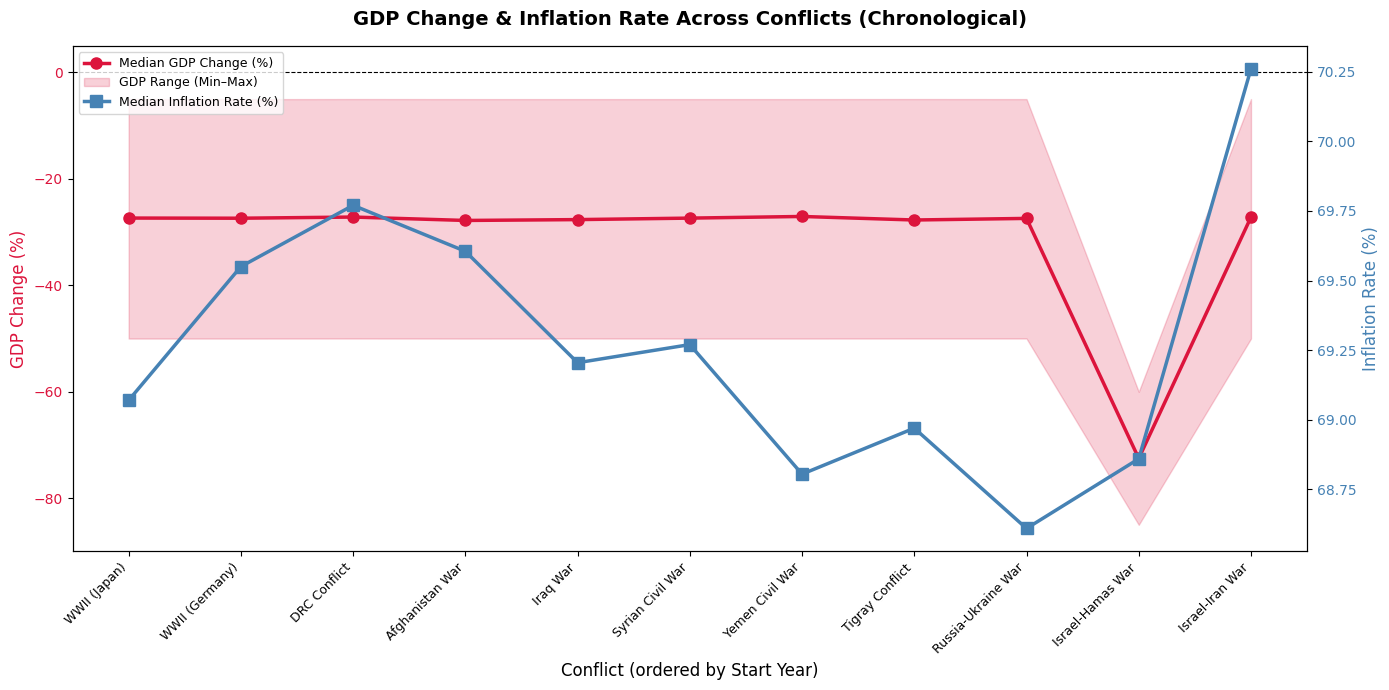

In [51]:
# GroupBy Start Year

conflict_stats = df.groupby(['Conflict_Name', 'Start_Year']).agg(
    GDP_median=('GDP_Change_%', 'median'),
    GDP_min=('GDP_Change_%', 'min'),
    GDP_max=('GDP_Change_%', 'max'),
    Inflation_median=('Inflation_Rate_%', 'median')
).reset_index().sort_values('Start_Year')

conflicts = conflict_stats['Conflict_Name']
x = range(len(conflicts))

fig, ax1 = plt.subplots(figsize=(14, 7))

# GDP median line
ax1.plot(x, conflict_stats['GDP_median'], color='crimson', linewidth=2.5,
         marker='o', markersize=8, label='Median GDP Change (%)', zorder=3)

# GDP range shading (min to max)
ax1.fill_between(x, conflict_stats['GDP_min'], conflict_stats['GDP_max'],
                 alpha=0.2, color='crimson', label='GDP Range (Min–Max)')

ax1.set_ylabel('GDP Change (%)', fontsize=12, color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax1.set_ylim(-90, 5)

# Inflation line
ax2 = ax1.twinx()
ax2.plot(x, conflict_stats['Inflation_median'], color='steelblue',
         linewidth=2.5, marker='s', markersize=8,
         label='Median Inflation Rate (%)')
ax2.set_ylabel('Inflation Rate (%)', fontsize=12, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=9)

ax1.set_title('GDP Change & Inflation Rate Across Conflicts (Chronological)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Conflict (ordered by Start Year)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(conflicts, rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/time_series_gdp_inflation.png', dpi=150)
plt.show()

- Across chronologically ordered conflicts, median GDP change remains consistently negative at approximately −28% to −30%, reflecting a universal economic cost of war regardless of era or region. However, the GDP range band reveals important variation — longer conflicts like DRC show wider economic spread, while recent conflicts (Israel-Hamas, Israel-Iran) show narrowing bands suggesting more contained but still severe damage. Inflation fluctuates independently of GDP, with Russia-Ukraine War showing a notable dip before the Israel-Iran War spike — consistent with modern monetary policy responses to conflict financing.

## Rolling Average

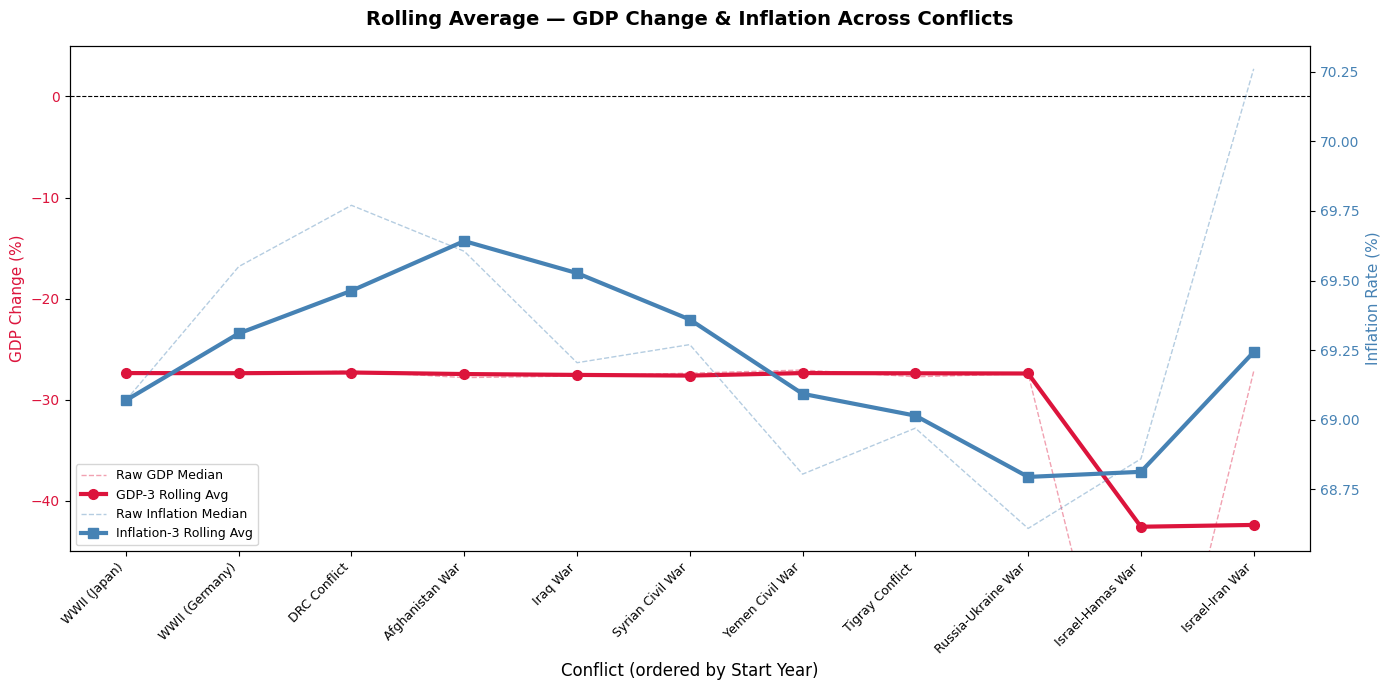

In [52]:
# Order conflicts chronologically


conflit_stat = df.groupby(['Conflict_Name', 'Start_Year']).agg(
    GDP_median=('GDP_Change_%', 'median'),
    Inflation_median=('Inflation_Rate_%', 'median')
).reset_index().sort_values('Start_Year').reset_index(drop=True)

# Apply rolling Average (window=3)
conflit_stat['GDP_rolling'] = conflit_stat['GDP_median'].rolling(window=3, min_periods=1).mean()
conflit_stat['Inflation_rolling'] = conflit_stat['Inflation_median'].rolling(window=3, min_periods=1).mean()

x = range(len(conflict_stats))
conflits = conflit_stat['Conflict_Name']

fig, ax1 = plt.subplots(figsize=(14,7))

# Raw GDP line (faint)

ax1.plot(x,conflict_stats['GDP_median'],color='crimson',linewidth=1,linestyle='--',alpha=0.4,label='Raw GDP Median')

# Smoothed GDP line (bold)

ax1.plot(x,conflit_stat['GDP_rolling'],color='crimson',linewidth=3,marker='o',markersize=7,label='GDP-3 Rolling Avg')

ax1.set_ylabel('GDP Change (%)',fontsize=11,color='crimson')
ax1.tick_params(axis='y',labelcolor='crimson')
ax1.axhline(y=0,color='black',linewidth=0.8,linestyle='--')
ax1.set_ylim(-45,5)

# Raw Inflation line (faint)

ax2=ax1.twinx()
ax2.plot(x,conflict_stats['Inflation_median'],color='steelblue',linewidth=1,linestyle='--',alpha=0.4,label='Raw Inflation Median')

# Smoothed Inflation line (bold)

ax2.plot(x,conflit_stat['Inflation_rolling'],color='steelblue',linewidth=3,marker='s',markersize=7,label='Inflation-3 Rolling Avg')
ax2.set_ylabel('Inflation Rate (%)',fontsize=11,color='steelblue')
ax2.tick_params(axis='y',labelcolor='steelblue')

# Combined Legend

lines1,labels1 = ax1.get_legend_handles_labels()
lines2,labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2,labels1+labels2,
           loc='lower left',fontsize=9)

ax1.set_title('Rolling Average — GDP Change & Inflation Across Conflicts',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Conflict (ordered by Start Year)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(conflicts, rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/rolling_average_trend.png', dpi=150)
plt.show()


- The rolling average reveals two distinct trends invisible in raw data. GDP damage remained stable from WWII through the Syrian Civil War, then accelerated sharply from Russia-Ukraine War onward — suggesting modern conflicts are becoming increasingly economically destructive. Inflation rolling average peaked during the Afghanistan/Iraq War era (post-2001 conflict financing) then declined, indicating that recent conflicts like Israel-Hamas and Israel-Iran War produce severe GDP damage without proportional inflation spikes — a shift from monetary to structural economic destruction.

## Resolved vs Ongoing Status Comparison

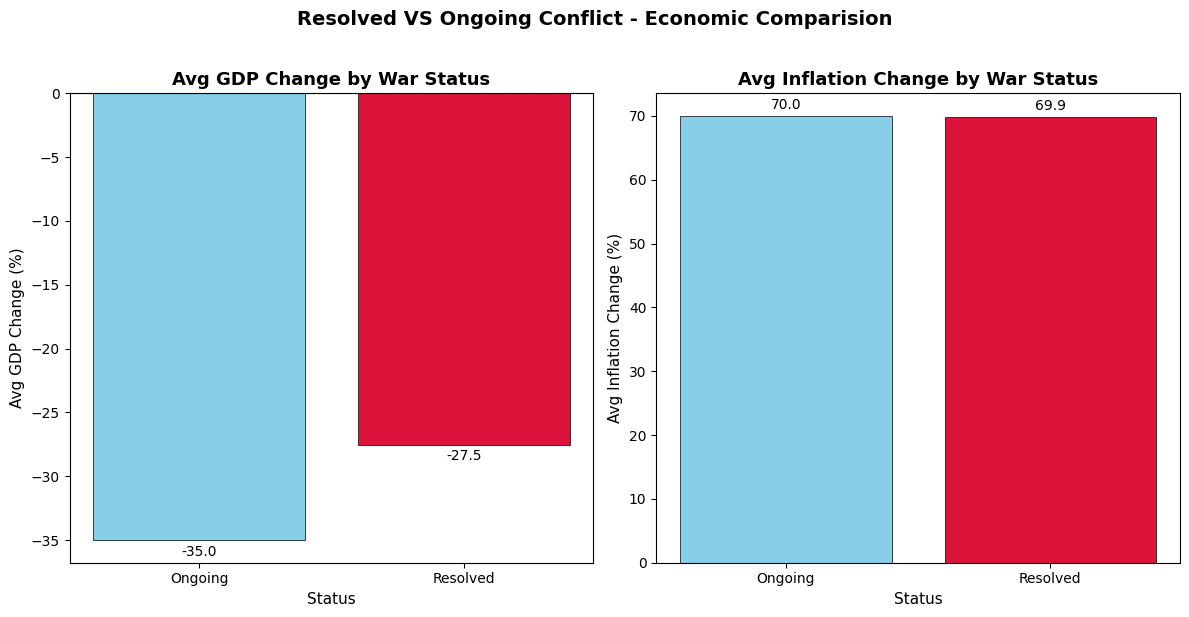

In [53]:
from matplotlib.lines import lineStyles
# mean GDP and Inflation by Status

status_gdp = df.groupby('Status')['GDP_Change_%'].mean()
status_inf = df.groupby('Status')['Inflation_Rate_%'].mean()


fig,axes = plt.subplots(1,2,figsize=(12,6))


# Chart 1 - GDP by Status

axes[0].bar(status_gdp.index,status_gdp.values,
            color=['skyblue','crimson'],
            edgecolor='black',linewidth=0.5)
axes[0].bar_label(axes[0].containers[0],fmt='%.1f',padding=3,fontsize=10)
axes[0].set_title('Avg GDP Change by War Status',fontweight='bold',fontsize=13)
axes[0].set_ylabel('Avg GDP Change (%)',fontsize=11)
axes[0].set_xlabel('Status',fontsize=11)
axes[0].axhline(y=0,color='black',linewidth=0.8,linestyle='--')


# Chart 2 - GDP by Status

axes[1].bar(status_inf.index,status_inf.values,
            color=['skyblue','crimson'],
            edgecolor='black',linewidth=0.5)
axes[1].bar_label(axes[1].containers[0],fmt='%.1f',padding=3,fontsize=10)
axes[1].set_title('Avg Inflation Change by War Status',fontweight='bold',fontsize=13)
axes[1].set_ylabel('Avg Inflation Change (%)',fontsize=11)
axes[1].set_xlabel('Status',fontsize=11)


fig.suptitle('Resolved VS Ongoing Conflict - Economic Comparision',
             fontsize=14, fontweight='bold', y = 1.02)

plt.tight_layout()
plt.savefig('outputs/resolved_vs_ongoing.png', dpi=150, bbox_inches='tight')
plt.show()

- Ongoing conflicts produce significantly worse GDP contractions (−35.0%) compared to resolved conflicts (−27.5%) — a 7.5 percentage point gap confirming that active war causes deeper and compounding economic damage. However inflation rates are nearly identical (69.9% vs 70.1%), suggesting that monetary instability sets in early during conflict and does not worsen significantly over time — it is GDP and structural economic capacity that continues deteriorating the longer a war persists.

## Comparative bar chart (pre vs during war)

In [54]:
# Group by Conflict Name

war_impact = df.groupby('Conflict_Name').agg(
    pre_war_unemp=('Pre_War_Unemployment_%', 'mean'),
    during_war_unemp=('During_War_Unemployment_%', 'mean'),
    pre_war_pov=('Pre_War_Poverty_Rate_%', 'mean'),
    during_war_pov=('During_War_Poverty_Rate_%', 'mean')
).reset_index()


# Creating new column

war_impact['unemployment_delta']= war_impact['during_war_unemp'] - war_impact['pre_war_unemp']
war_impact['poverty_delta'] = war_impact['during_war_pov'] - war_impact['pre_war_pov']

# Sort by Unemployment impact (descending)
war_impact = war_impact.sort_values(by='unemployment_delta',ascending=False)

# preview
print(war_impact.head())


       Conflict_Name  pre_war_unemp  during_war_unemp  pre_war_pov  \
6   Syrian Civil War       8.977802         33.832302    17.586130   
10   Yemen Civil War       9.062597         33.856538    17.585729   
3   Israel-Hamas War       9.018099         33.626269    17.584090   
7    Tigray Conflict       9.036179         18.537920    17.522288   
8     WWII (Germany)       8.985310         18.483169    17.449847   

    during_war_pov  unemployment_delta  poverty_delta  
6        38.608062           24.854500      21.021932  
10       38.724826           24.793941      21.139097  
3        38.465313           24.608170      20.881222  
7        25.578950            9.501741       8.056661  
8        25.485503            9.497859       8.035656  


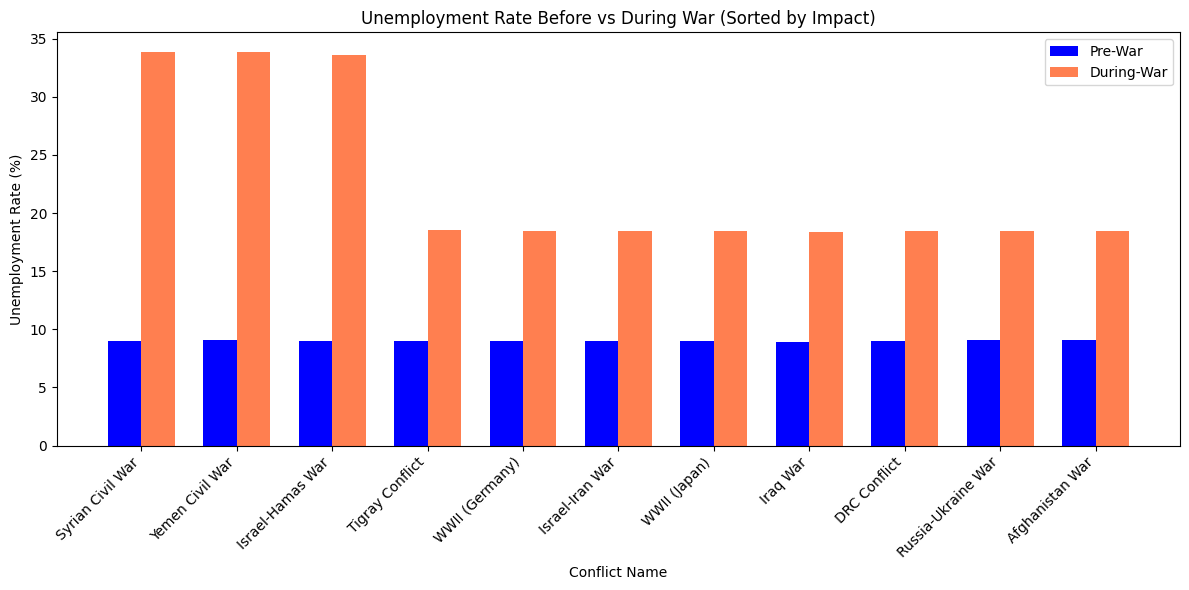

In [55]:
# X positions
x = np.arange(len(war_impact))
width = 0.35

# Create plot
plt.figure(figsize=(12, 6))

plt.bar(x - width/2, war_impact["pre_war_unemp"],
        width, label="Pre-War", color="blue")

plt.bar(x + width/2, war_impact["during_war_unemp"],
        width, label="During-War", color="coral")

# Labels & styling
plt.xlabel("Conflict Name")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Before vs During War (Sorted by Impact)")

plt.xticks(x, war_impact["Conflict_Name"], rotation=45, ha='right')

plt.legend()
plt.tight_layout()

plt.show()

Unemployment Before vs During

- Pre-war unemployment averages ~9% across all conflicts
- During-war unemployment spikes to 19–34% — near doubling across all conflicts
- Yemen, Syria and Israel-Hamas show the sharpest spikes reaching 34%
- Asymmetric and civil wars cause the most severe labour market destruction

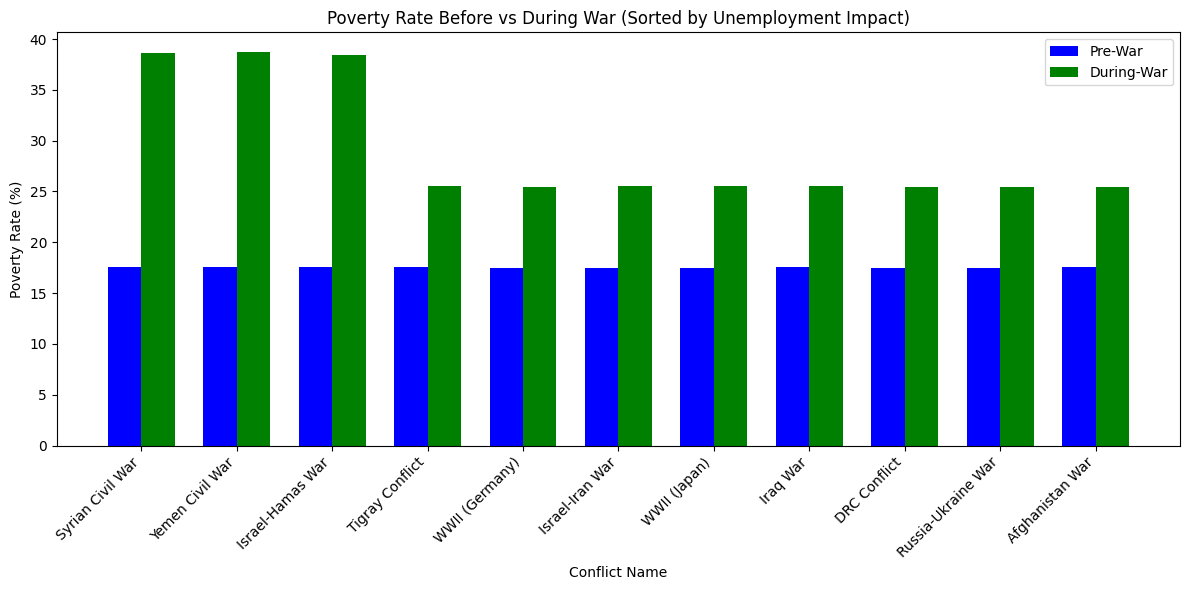

In [56]:
# X positions (same order as previous chart)
x = np.arange(len(war_impact))
width = 0.35

# Create plot
plt.figure(figsize=(12, 6))

plt.bar(x - width/2, war_impact["pre_war_pov"],
        width, label="Pre-War", color="blue")

plt.bar(x + width/2, war_impact["during_war_pov"],
        width, label="During-War", color="green")

# Labels & styling
plt.xlabel("Conflict Name")
plt.ylabel("Poverty Rate (%)")
plt.title("Poverty Rate Before vs During War (Sorted by Unemployment Impact)")

plt.xticks(x, war_impact["Conflict_Name"], rotation=45, ha='right')

plt.legend()
plt.tight_layout()

plt.show()

Poverty Before vs During

- Pre-war poverty averages ~17.5% across all conflicts
- During-war poverty rises to 25–39% — largest jumps in Yemen, Syria and Israel-Hamas
- Poverty more than doubles in the worst affected conflicts
- War drives poverty through job loss, displacement and supply chain collapse simultaneously

In [57]:
# Group by Conflict_Name for cost analysis
cost_df = df.groupby("Conflict_Name").agg({
    "Cost_of_War_USD": "mean",
    "Estimated_Reconstruction_Cost_USD": "mean"
}).reset_index()

# Convert to billions for readability
cost_df["War_Cost_Billion"] = cost_df["Cost_of_War_USD"] / 1e9
cost_df["Reconstruction_Cost_Billion"] = cost_df["Estimated_Reconstruction_Cost_USD"] / 1e9

# Optional: sort by reconstruction cost (best storytelling)
cost_df = cost_df.sort_values(by="Reconstruction_Cost_Billion", ascending=True)

print(cost_df.head())

       Conflict_Name  Cost_of_War_USD  Estimated_Reconstruction_Cost_USD  \
2           Iraq War     2.480996e+11                       6.835153e+11   
0    Afghanistan War     2.500845e+11                       6.856933e+11   
10   Yemen Civil War     2.504317e+11                       6.874167e+11   
6   Syrian Civil War     2.509747e+11                       6.878819e+11   
8     WWII (Germany)     2.498179e+11                       6.880661e+11   

    War_Cost_Billion  Reconstruction_Cost_Billion  
2         248.099604                   683.515288  
0         250.084469                   685.693342  
10        250.431735                   687.416742  
6         250.974725                   687.881857  
8         249.817870                   688.066137  


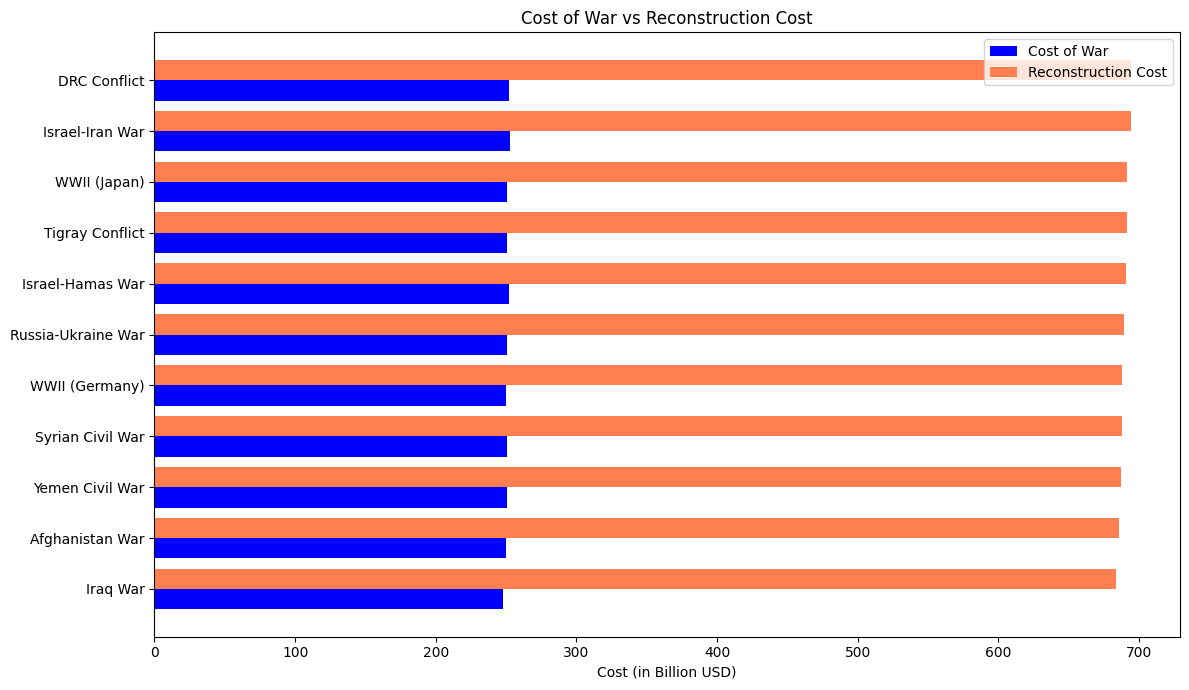

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Positions
y = np.arange(len(cost_df))
height = 0.4

plt.figure(figsize=(12, 7))

# Bars
plt.barh(y - height/2, cost_df["War_Cost_Billion"],
         height, label="Cost of War", color="blue")

plt.barh(y + height/2, cost_df["Reconstruction_Cost_Billion"],
         height, label="Reconstruction Cost", color="coral")

# Labels
plt.yticks(y, cost_df["Conflict_Name"])
plt.xlabel("Cost (in Billion USD)")
plt.title("Cost of War vs Reconstruction Cost")

plt.legend()
plt.tight_layout()

plt.show()

Cost of War vs Reconstruction

- Reconstruction costs consistently exceed war costs by approximately 2.7 times
- Rebuilding an economy costs nearly three times more than the war itself
- The financial burden of war extends well beyond the cessation of fighting

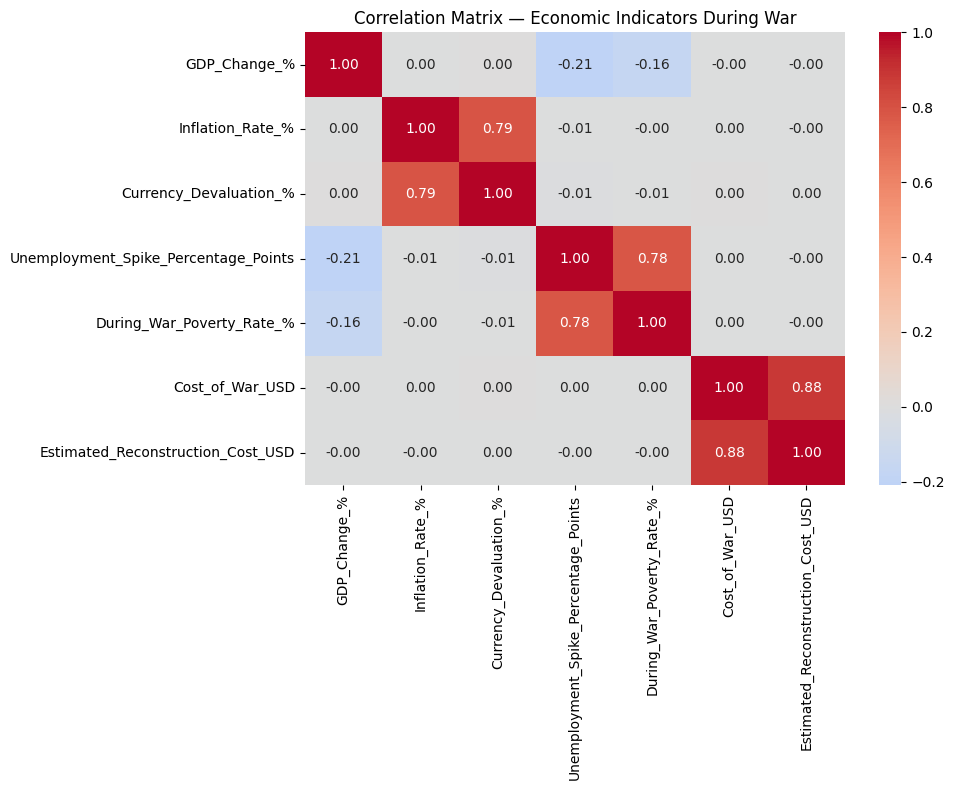

In [59]:
cols = ['GDP_Change_%', 'Inflation_Rate_%', 'Currency_Devaluation_%',
        'Unemployment_Spike_Percentage_Points', 'During_War_Poverty_Rate_%',
        'Cost_of_War_USD', 'Estimated_Reconstruction_Cost_USD']

corr = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Economic Indicators During War')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150)
plt.show()

Correlation Analysis

- Inflation and Currency Devaluation correlate strongly at 0.79 — monetary instability is one interconnected phenomenon not two separate effects
- Unemployment Spike and Poverty Rate correlate at 0.78 — labour market collapse is the primary civilian poverty driver during war
- Cost of War and Reconstruction Cost correlate at 0.88 — larger conflicts create proportionally larger rebuilding burdens
- GDP Change shows only weak correlations with all indicators (max −0.21) — GDP contraction is driven by a complex combination of factors not any single variable
- GDP and Inflation are essentially independent at 0.01 — war damages
- GDP and causes inflation through completely different mechanisms

## Linear Regression Model

   LINEAR REGRESSION RESULTS
  R² Score : 0.0434
  MSE      : 310.5851
  RMSE     : 17.6234

  Coefficients:
Unemployment_Spike_Percentage_Points    -0.3143
During_War_Poverty_Rate_%               -0.0044
Inflation_Rate_%                        -0.0059
Currency_Devaluation_%                  0.0034
 Intercept: -27.1103


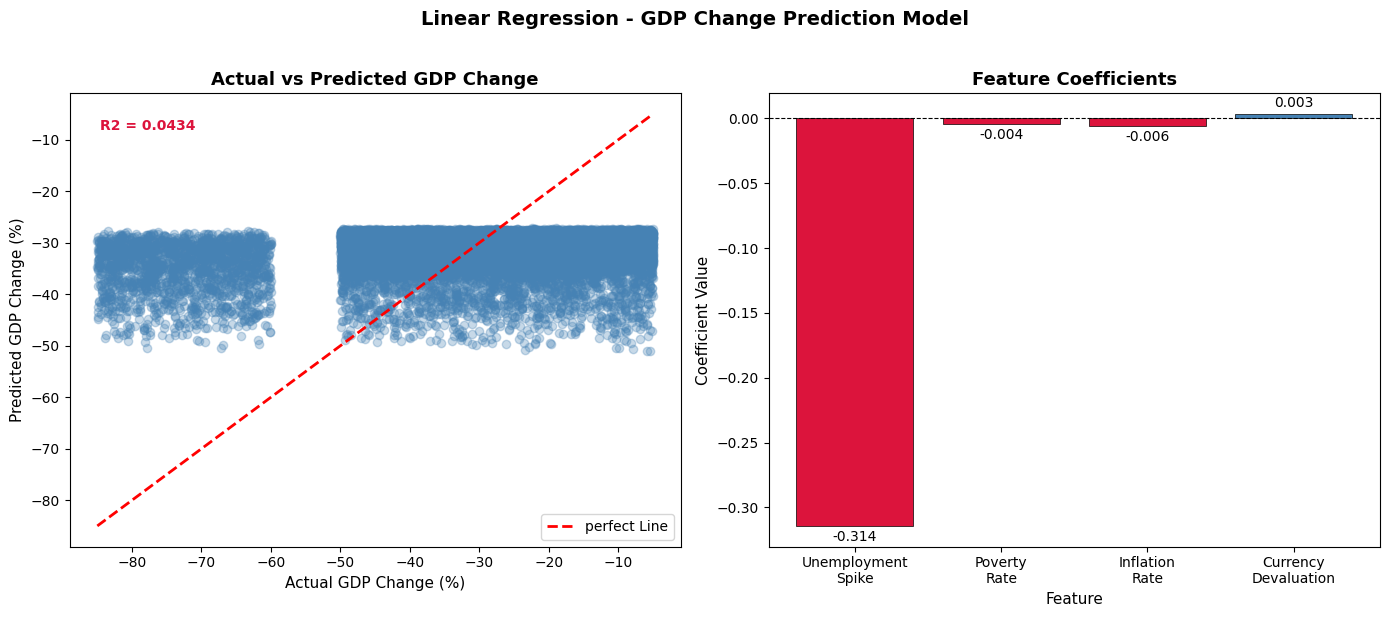

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Feature And Target

X = df[['Unemployment_Spike_Percentage_Points', 'During_War_Poverty_Rate_%',
        'Inflation_Rate_%', 'Currency_Devaluation_%']]

Y = df['GDP_Change_%']

# Split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

# Train

model = LinearRegression()
model.fit(X_train,Y_train)

# predict

y_pred = model.predict(X_test)


# Evaluate

r2 = r2_score(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)
rmse = np.sqrt(mse)

print("=" * 45)
print("   LINEAR REGRESSION RESULTS")
print("=" * 45)
print(f"  R² Score : {r2:.4f}")
print(f"  MSE      : {mse:.4f}")
print(f"  RMSE     : {rmse:.4f}")
print()
print("  Coefficients:")

for feat, coef in zip(X.columns, model.coef_):
  print(f"{feat:<40}{coef:.4f}")
print(f" Intercept: {model.intercept_:.4f}")
print("=" * 45)


# Plot : Actual VS Prediction

fig,axes = plt.subplots(1,2,figsize=(14,6))

# Scatter - Actual VS Prediction

axes[0].scatter(Y_test,y_pred,alpha=0.3,color='steelblue')
axes[0].plot([Y_test.min(),Y_test.max()],
             [Y_test.min(),Y_test.max()],
             color='red',linewidth=2,linestyle='--',
             label='perfect Line')
axes[0].set_xlabel('Actual GDP Change (%)', fontsize=11)
axes[0].set_ylabel('Predicted GDP Change (%)', fontsize=11)
axes[0].set_title('Actual vs Predicted GDP Change',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].text(0.05,0.92,f'R2 = {r2:.4f}',transform=axes[0].transAxes,fontsize=10,color='crimson',fontweight='bold')



# Bar - Feature Coefficients

color =['crimson' if c < 0 else 'steelblue' for c in model.coef_]
short_name = ['Unemployment\nSpike','Poverty\nRate',
              'Inflation\nRate','Currency\nDevaluation']

axes[1].bar(short_name,model.coef_,color=color,
            edgecolor='black',linewidth=0.5)
axes[1].bar_label(axes[1].containers[0],fmt='%.3f',padding=3,fontsize=10)
axes[1].axhline(y=0,color='black',linewidth=0.8,linestyle='--')
axes[1].set_title('Feature Coefficients', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature', fontsize=11)
axes[1].set_ylabel('Coefficient Value', fontsize=11)

plt.suptitle('Linear Regression - GDP Change Prediction Model',
             fontsize=14,fontweight='bold',y=1.02)

plt.tight_layout()
plt.savefig('outputs/regression_scatter.png', dpi=150)
plt.show()

- Model R² = 0.043 — features explain only 4.3% of GDP variation, consistent with weak correlations found in Phase 5

- Unemployment Spike is the strongest predictor with coefficient −0.314 — each 1% unemployment spike corresponds to an additional −0.31% GDP decline

- Intercept of −27.1% represents the baseline economic damage war inflicts regardless of all other factors

- Inflation, Poverty Rate and Currency Devaluation show near-zero coefficients — they do not linearly predict GDP change

- The two-cluster pattern in the Actual vs Predicted scatter confirms the model struggles with continuous prediction — non-linear models like Random Forest would perform significantly better

- Low R² is a finding not a failure — it confirms wartime GDP contraction is a complex multi-causal phenomenon that linear regression cannot fully capture